In [1]:
import numpy as np
import matplotlib.pyplot as plt
import odl
from odl.contrib import tomo

### 3D

In [2]:

import odl
from odl.contrib.tomo import elekta_icon_geometry  # preset geometry (ODL contrib)

# Define the reconstruction (volume) space
recospace = odl.uniform_discr(
    min_pt=[-112, -112, 0],
    max_pt=[ 112,  112, 224],
    shape=(128, 128, 128),
    dtype=np.float32
)

# Define the acquisition geometry (Elekta Icon preset)
geometry = elekta_icon_geometry(num_angles=128)

# Create the ray transform operator A : recospace -> dataspace
raytrafo = odl.tomo.RayTransform(
    vol_space=recospace,
    geometry=geometry, 
    impl="astra_cuda"
)

# The dataspace is the range of the operator
dataspace = raytrafo.range


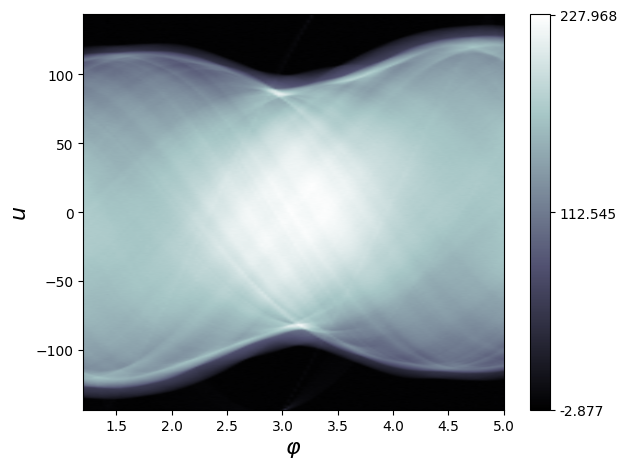

<Figure size 640x480 with 0 Axes>

In [3]:
arr_sinogram = np.load(r"../data/noisy_sinogram.npy")
arr_sinogram.astype(np.float32)
noisy_sinogram = dataspace.element(arr_sinogram)
noisy_sinogram.show()
plt.close()

In [5]:
def Huber_Reconstruction(raytrafo_op, grad_op, x, data_noisy, 
                         dataspace, niter, lam, epsilon, alpha0):
    huber_norm = odl.solvers.Huber(space=grad_op.range, gamma=epsilon)
    regularizer = lam * odl.solvers.functional.functional.FunctionalComp(huber_norm,grad_op)
    
    L2_norm = odl.solvers.L2NormSquared(dataspace).translated(data_noisy)
    least_sq = data_fidelity = 0.5 * odl.solvers.functional.functional.FunctionalComp(L2_norm,raytrafo_op)
    
    f = least_sq + regularizer
    # same idea for the line_search as for the 2D case
    line_search = odl.solvers.BacktrackingLineSearch(function=f, max_num_iter=20, alpha=alpha0, tau=0.5, discount=1e-4, estimate_step=True)  # Armijo rule
    odl.solvers.smooth.gradient.steepest_descent(f,x, maxiter=niter, line_search=line_search)
    
    return x
    

/home/ahopkins/KTH_TTMAM/SF2529_HT25/.venv/lib/python3.10/site-packages/odl/util/utility.py:1398: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_requirements


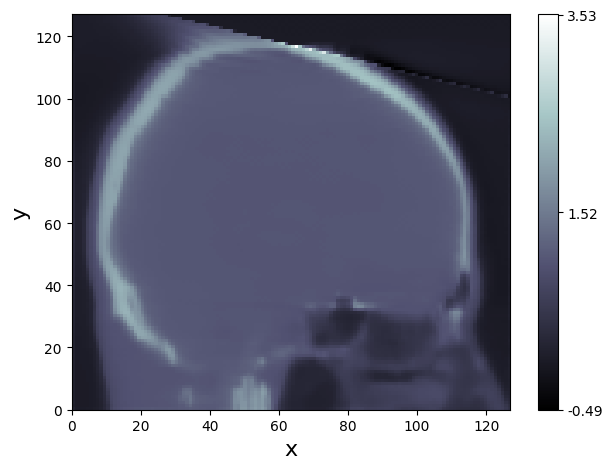

<Figure size 640x480 with 0 Axes>

In [5]:

grad_op = odl.Gradient(domain=recospace)

epsilon = 1.5e-5
lam = 1.5
alpha0 = 1 / raytrafo.norm(estimate=True)**2

x0 = recospace.zero()
x = Huber_Reconstruction(raytrafo_op=raytrafo, grad_op=grad_op, x = x0, 
                         data_noisy=noisy_sinogram, dataspace=dataspace, 
                         niter=20, lam=lam, epsilon=epsilon, alpha0=alpha0)

x[64, :, :].show()
plt.close()


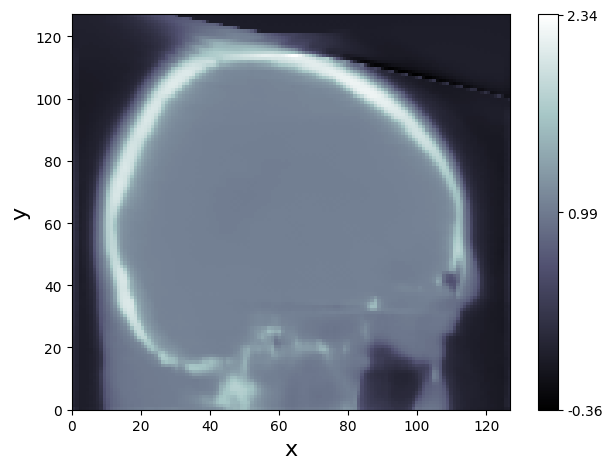

<Figure size 640x480 with 0 Axes>

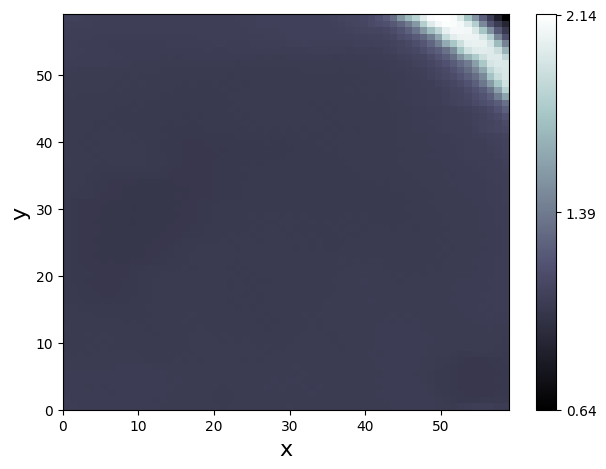

<Figure size 640x480 with 0 Axes>

In [6]:
slice_x = 50
x[slice_x, :, :].show()
x[slice_x, 40:100, 40:100].show()
plt.close()

In [103]:
import numpy as np

def enhance_brain_contrast(img, lower_pct=5, upper_pct=85, gamma=1.4):

    img = img.astype(float)

    # 1) crude head mask to ignore air/background
    head_mask = img > np.percentile(img, 3)

    # 2) robust window from soft-tissue percentiles
    lo = np.percentile(img[head_mask], lower_pct)
    hi = np.percentile(img[head_mask], upper_pct)

    # 3) clamp to window and normalize
    win = np.clip(img, lo, hi)
    win = (win - lo) / (hi - lo + 1e-12)

    # 4) gamma correction to reduce highlights
    out = np.power(win, gamma)

    return out


(128, 128, 128)


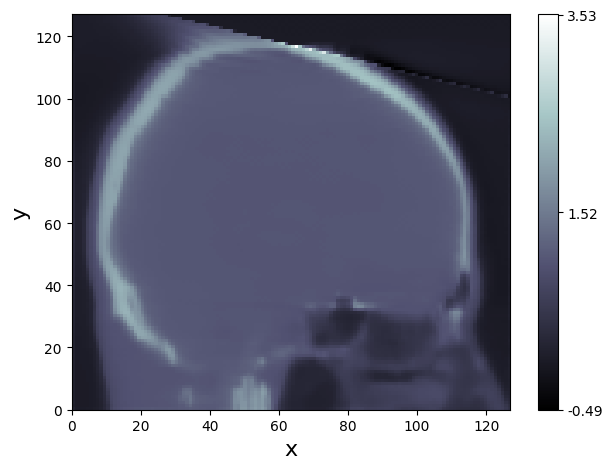

<Figure size 640x480 with 0 Axes>

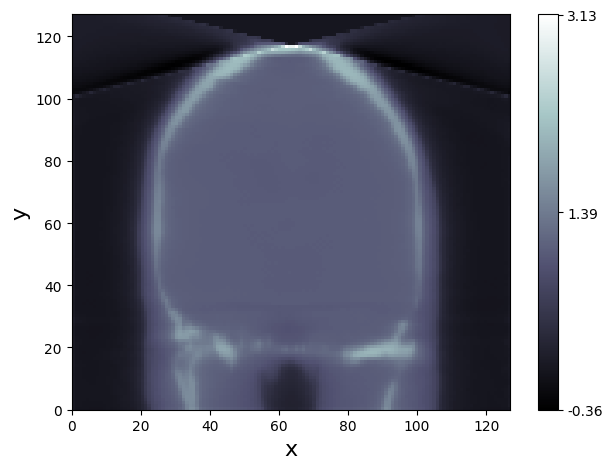

<Figure size 640x480 with 0 Axes>

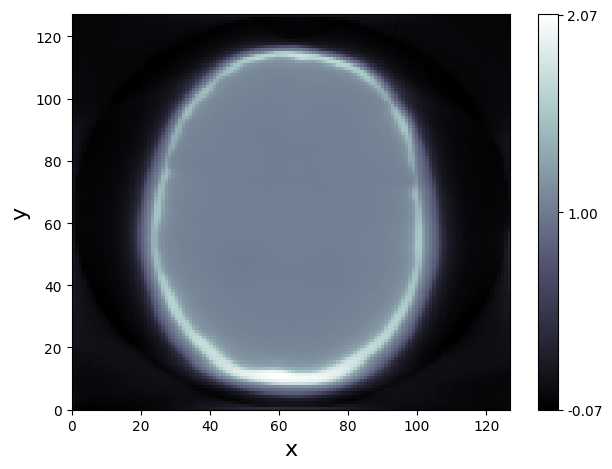

<Figure size 640x480 with 0 Axes>

In [7]:
# x, y, z
print(x.shape)
x[64, :, :].show()
x[:, 64, :].show()        # [:, :, 64]
x[:, :, 64].show()        # [:, :, 64]
plt.close()

### Check differences in the solution for different $\lambda$

In [104]:
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

plot_folder = r"Plots_zoomed"
dest_folder = os.path.join(plot_folder, r"3D_slices/vary_lambda")

# Make sure the folder exists
os.makedirs(dest_folder, exist_ok=True)

lambdas = [0.01, 0.5, 1.5, 5, 20, 40]

grad_op = odl.Gradient(domain=recospace)

epsilon = 1.5e-5
alpha0 = 1 / raytrafo.norm(estimate=True)**2

for lam in tqdm(lambdas, desc='λ sweep', dynamic_ncols=True):
    x0 = recospace.zero()
    x = Huber_Reconstruction(raytrafo_op=raytrafo, grad_op=grad_op, x=x0,
                             data_noisy=noisy_sinogram, dataspace=dataspace,
                             niter=50, lam=lam, epsilon=epsilon, alpha0=alpha0)
    
    # Extract slices
    x_slice = x[64, 32:96, 32:96]
    y_slice = x[32:96, 64, 32:96]
    z_slice = x[32:96, 32:96, 64]
    
    
    # Plot and save each slice
    for axis, slice_data in zip(["x", "y", "z"], [x_slice, y_slice, z_slice]):
        slice_data = enhance_brain_contrast(slice_data, lower_pct=5,
                                            upper_pct=85, gamma=1.4)
        plt.imshow(slice_data, cmap="gray")
        plt.axis("off")  # optional, hide axes
        filename = f"slice_{axis}_lambda_{lam}.png"
        filepath = os.path.join(dest_folder, filename)
        plt.savefig(filepath, bbox_inches="tight", pad_inches=0, dpi=300)
        plt.close()


λ sweep: 100%|██████████| 6/6 [19:55<00:00, 199.29s/it]


### Check differences in the solution during iterations

In [105]:
import os
import matplotlib.pyplot as plt

plot_folder = r"Plots_zoomed"
lam = 1.5
dest_folder = os.path.join(plot_folder, f"3D_slices/iter_lam_{lam}")

# Make sure the folder exists
os.makedirs(dest_folder, exist_ok=True)

grad_op = odl.Gradient(domain=recospace)
epsilon = 1.5e-5
alpha0 = 1 / raytrafo.norm(estimate=True)**2

nsteps = 70
chunk = 5

x0 = recospace.zero()
x = x0
for iter in tqdm(range(0, nsteps + 1, chunk), desc="Iterations", dynamic_ncols=True):  # include final step
    x = Huber_Reconstruction(
        raytrafo_op=raytrafo, grad_op=grad_op, x=x,
        data_noisy=noisy_sinogram, dataspace=dataspace,
        niter=chunk,  # run only 'chunk' steps each loop
        lam=lam, epsilon=epsilon, alpha0=alpha0
    )

    # Extract slices
    x_slice = x[64, 32:96, 32:96]
    y_slice = x[32:96, 64, 32:96]
    z_slice = x[32:96, 32:96, 64]

    # Save each slice
    for axis, slice_data in zip(["x", "y", "z"], [x_slice, y_slice, z_slice]):
        slice_data = enhance_brain_contrast(slice_data, lower_pct=5,
                                            upper_pct=85, gamma=1.4)
        plt.imshow(slice_data, cmap="gray")
        plt.axis("off")
        filename = f"slice_{axis}_iter_{int(iter):03d}.png"
        filepath = os.path.join(dest_folder, filename)
        plt.savefig(filepath, bbox_inches="tight", pad_inches=0, dpi=300)
        plt.close()


Iterations: 100%|██████████| 15/15 [05:06<00:00, 20.47s/it]


### Comparison with the filtered back-projection

In [113]:
import os
import numpy as np
import matplotlib.pyplot as plt

plot_folder = r"Plots_zoomed_new_params"
lam = 1.1
dest_folder = os.path.join(plot_folder, "3D_slices", "fbp_op")
os.makedirs(dest_folder, exist_ok=True)

grad_op = odl.Gradient(domain=recospace)
epsilon = 1.5e-5
alpha0 = 1 / raytrafo.norm(estimate=True)**2

# Huber reconstruction
x0 = recospace.zero()
x_huber = Huber_Reconstruction(
    raytrafo_op=raytrafo, grad_op=grad_op, x=x0,
    data_noisy=noisy_sinogram, dataspace=dataspace,
    niter=100, lam=lam, epsilon=epsilon, alpha0=alpha0
)

# Different filtered backprojections
filters = ['Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann']
recons = [("Huber (λ={})".format(lam), x_huber)]

freq_scaling = 0.12  # change this to test smoothing, 
                    # lower value -> more smoothing (less high frequency content)
for filt in filters:
    FBP = odl.tomo.analytic.filtered_back_projection.fbp_op(
        raytrafo, padding=True, filter_type=filt, frequency_scaling=freq_scaling
    )
    recon = FBP(noisy_sinogram)
    recons.append((f"FBP: {filt}", recon))

# Function to plot chosen slice orientation
def plot_orientation(orientation, slice_idx, save_name):
    imgs, labels = [], []
    for label, vol in recons:
        if orientation == "x":
            img = vol[slice_idx, 32:96, 32:96]
        elif orientation == "y":
            img = vol[32:96, slice_idx, 32:96]
        elif orientation == "z":
            img = vol[32:96, 32:96, slice_idx]
        else:
            raise ValueError("orientation must be 'x','y', or 'z'")
        imgs.append(np.asarray(img))
        labels.append(label)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()
    for ax, img, label in zip(axes, imgs, labels):
        img = enhance_brain_contrast(img, lower_pct=5,
                                            upper_pct=85, gamma=1.4)
        ax.imshow(img, cmap="gray")
        ax.set_title(label, fontsize=10)
        ax.axis("off")

    fig.suptitle(
        f"Comparison of {orientation.upper()}-slice={slice_idx}, freq_scaling={freq_scaling}",
        fontsize=14
    )
    plt.tight_layout()
    fig.savefig(os.path.join(dest_folder, save_name), dpi=300, bbox_inches="tight")
    plt.close(fig)

# Make the three plots
slice_nr = 64
plot_orientation("x", slice_nr, f"compare_xslice{slice_nr}_freq{freq_scaling}.png")
plot_orientation("y", slice_nr, f"compare_yslice{slice_nr}_freq{freq_scaling}.png")
plot_orientation("z", slice_nr, f"compare_zslice{slice_nr}_freq{freq_scaling}.png")

print(f"Saved comparison plots to {dest_folder}")


Saved comparison plots to Plots_zoomed_new_params/3D_slices/fbp_op


/tmp/ipykernel_768/2688357028.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


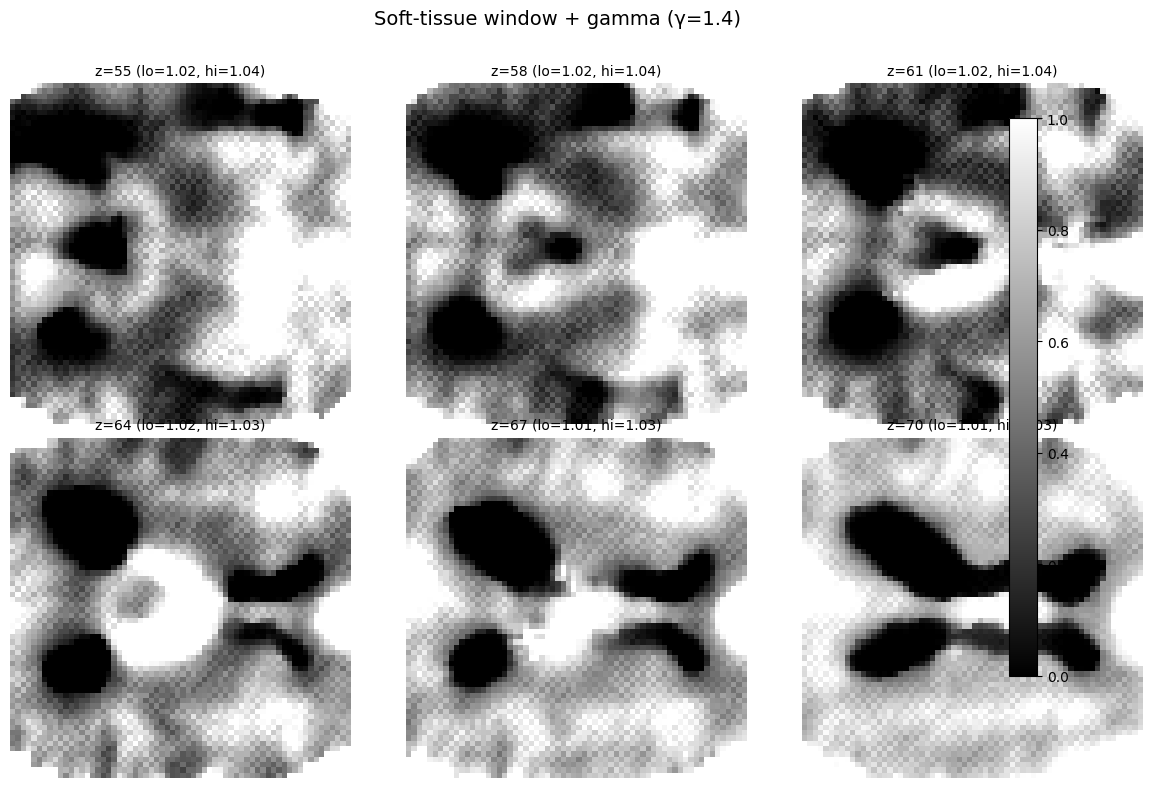

In [114]:
import numpy as np
import matplotlib.pyplot as plt

label, solution = recons[0]     # 0: Huber, 1:5 fbp: 'Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann'

z_slices = [55, 58, 61, 64, 67, 70]
gamma = 1.4  # >1 darkens highlights; try 1.2–1.8

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

last_im = None
for ax, z in zip(axes, z_slices):
    img = solution[32:96, 32:96, z].asarray().astype(float)

    # 1) crude head mask to ignore air/background
    head_mask = img > np.percentile(img, 5)

    # 2) robust window from soft-tissue percentiles
    lo = np.percentile(img[head_mask], 5)
    hi = np.percentile(img[head_mask], 85)

    # 3) clamp to window and normalize
    win = np.clip(img, lo, hi)
    win = (win - lo) / (hi - lo + 1e-12)

    # 4) gamma to suppress highlights & open mid-tones
    out = win ** gamma

    last_im = ax.imshow(out, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"z={z} (lo={lo:.2f}, hi={hi:.2f})", fontsize=10)
    ax.axis('off')

# shared colorbar + nice spacing
fig.suptitle(f"Soft-tissue window + gamma (γ={gamma})", fontsize=14)
if last_im is not None:
    fig.colorbar(last_im, ax=axes.tolist(), fraction=0.03, pad=0.02)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


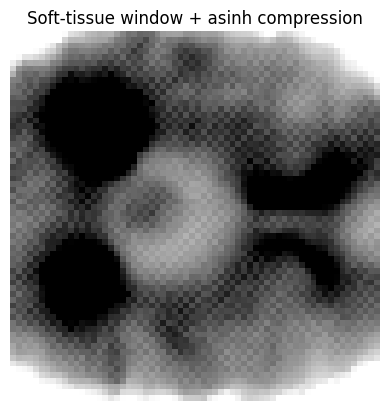

In [68]:
img = sol.astype(float)

head_mask = img > np.percentile(img, 10)
lo = np.percentile(img[head_mask], 5)
hi = np.percentile(img[head_mask], 95)  # keep a bit more top than A)

win = np.clip(img, lo, hi)
win = (win - lo) / (hi - lo + 1e-12)

k = 6  # strength of compression; 3–8 is typical
out = np.arcsinh(k * win) / np.arcsinh(k)

plt.imshow(out, cmap='gray', vmin=0, vmax=1)
plt.title("Soft-tissue window + asinh compression")
plt.axis('off')
plt.show()


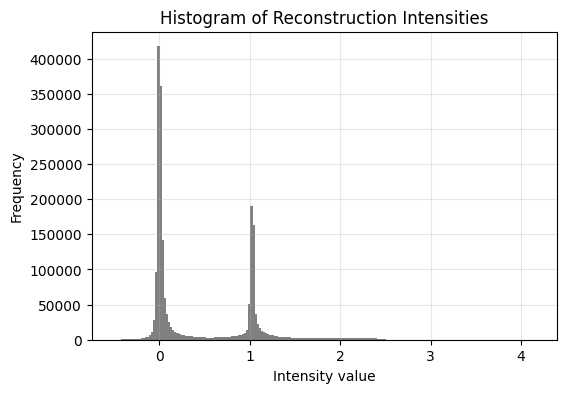

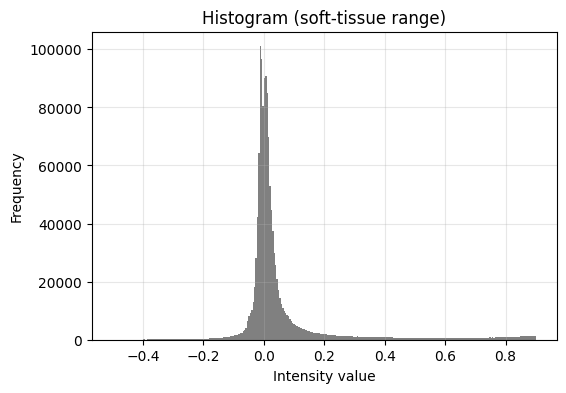

In [35]:
import matplotlib.pyplot as plt
import numpy as np

arr = solution.asarray().ravel()  # flatten to 1D

plt.figure(figsize=(6,4))
plt.hist(arr, bins=200, color='gray')
plt.title("Histogram of Reconstruction Intensities")
plt.xlabel("Intensity value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(6,4))
plt.hist(arr[(arr > -0.5) & (arr < 0.9)], bins=300, color='gray')
plt.title("Histogram (soft-tissue range)")
plt.xlabel("Intensity value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


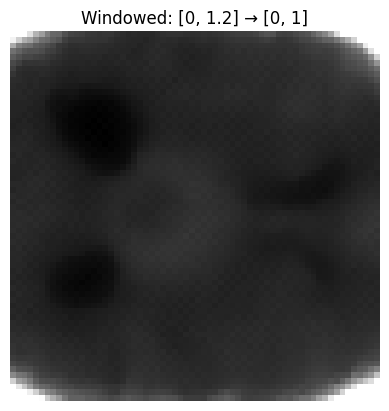

In [79]:
lo, hi = 0, 1.2                # window
windowed = (sol - lo) / (hi - lo + 1e-12)
windowed = np.clip(windowed, 0.0, 1.0)

plt.imshow(windowed, cmap='gray')
plt.title(f"Windowed: [{lo}, {hi}] → [0, 1]")
plt.axis('off')
plt.show()
